# 📊 Olist Brazilian E-Commerce Dataset - Complete Analysis
---
## Table of Contents
1. [Setup & Library Imports](#1-setup)
2. [Data Loading & Initial Overview](#2-data-loading)
3. [Data Cleaning & Preprocessing](#3-data-cleaning)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Business Analysis](#5-business-analysis)
   - 5.1 Sales & Revenue Analysis
   - 5.2 Customer Analysis
   - 5.3 Seller Analysis
   - 5.4 Product Analysis
   - 5.5 Delivery & Logistics Analysis
   - 5.6 Payment Analysis
   - 5.7 Review & Satisfaction Analysis
6. [Advanced Analysis](#6-advanced-analysis)
7. [Key Insights & Recommendations](#7-insights)

## 1. Setup & Library Imports <a class="anchor" id="1-setup"></a>

In [10]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Visualization Setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Data Loading & Initial Overview <a class="anchor" id="2-data-loading"></a>

In [9]:
# Load all datasets
print("Loading datasets...\n")

# Update this path to your data location
base_path = "/goinfre/yelmajdo/data/"

orders = pd.read_csv(f'{base_path}olist_orders_dataset.csv')
order_items = pd.read_csv(f'{base_path}olist_order_items_dataset.csv')
order_payments = pd.read_csv(f'{base_path}olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(f'{base_path}olist_order_reviews_dataset.csv')
products = pd.read_csv(f'{base_path}olist_products_dataset.csv')
customers = pd.read_csv(f'{base_path}olist_customers_dataset.csv')
sellers = pd.read_csv(f'{base_path}olist_sellers_dataset.csv')
geolocation = pd.read_csv(f'{base_path}olist_geolocation_dataset.csv')
category_translation = pd.read_csv(f'{base_path}product_category_name_translation.csv')

print("All datasets loaded successfully!")

Loading datasets...

All datasets loaded successfully!


In [5]:
# Dataset dimensions summary
datasets_info = {
    'Dataset': ['Orders', 'Order Items', 'Order Payments', 'Order Reviews', 
                'Products', 'Customers', 'Sellers', 'Geolocation', 'Category Translation'],
    'Rows': [orders.shape[0], order_items.shape[0], order_payments.shape[0], 
             order_reviews.shape[0], products.shape[0], customers.shape[0], 
             sellers.shape[0], geolocation.shape[0], category_translation.shape[0]],
    'Columns': [orders.shape[1], order_items.shape[1], order_payments.shape[1], 
                order_reviews.shape[1], products.shape[1], customers.shape[1], 
                sellers.shape[1], geolocation.shape[1], category_translation.shape[1]]
}

summary_df = pd.DataFrame(datasets_info)
summary_df['Memory (MB)'] = [
    orders.memory_usage(deep=True).sum() / 1024**2,
    order_items.memory_usage(deep=True).sum() / 1024**2,
    order_payments.memory_usage(deep=True).sum() / 1024**2,
    order_reviews.memory_usage(deep=True).sum() / 1024**2,
    products.memory_usage(deep=True).sum() / 1024**2,
    customers.memory_usage(deep=True).sum() / 1024**2,
    sellers.memory_usage(deep=True).sum() / 1024**2,
    geolocation.memory_usage(deep=True).sum() / 1024**2,
    category_translation.memory_usage(deep=True).sum() / 1024**2
]

print("-- DATASET DIMENSIONS SUMMARY")
display(summary_df.style.background_gradient(cmap='Blues', subset=['Rows', 'Memory (MB)']))

-- DATASET DIMENSIONS SUMMARY


,Dataset,Rows,Columns,Memory (MB)
0,Orders,99441,8,52.937277
1,Order Items,112650,7,35.989649
2,Order Payments,103886,5,16.229413
3,Order Reviews,99224,7,39.124777
4,Products,32951,9,6.296564
5,Customers,99441,5,26.586405
6,Sellers,3095,4,0.588048
7,Geolocation,1000163,5,129.380595
8,Category Translation,71,2,0.008999


### 2.1 Initial Data Inspection

In [8]:
# Check missing values across all datasets
print("-- MISSING VALUES ANALYSIS")

datasets_dict = {
    'orders': orders,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'products': products,
    'customers': customers,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_translation': category_translation
}

for name, df in datasets_dict.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Values': missing.values,
        'Percentage (%)': missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing Values'] > 0]
    
    if len(missing_df) > 0:
        print(f"\n- {name.upper()} - Missing Values:")
        display(missing_df)
    else:
        print(f"\n- {name.upper()} - No missing values")

-- MISSING VALUES ANALYSIS

- ORDERS - Missing Values:


,Column,Missing Values,Percentage (%)
4,order_approved_at,160,0.16
5,order_delivered_carrier_date,1783,1.79
6,order_delivered_customer_date,2965,2.98



- ORDER_ITEMS - No missing values

- ORDER_PAYMENTS - No missing values

- ORDER_REVIEWS - Missing Values:


,Column,Missing Values,Percentage (%)
3,review_comment_title,87656,88.34
4,review_comment_message,58247,58.70



- PRODUCTS - Missing Values:


,Column,Missing Values,Percentage (%)
1,product_category_name,610,1.85
2,product_name_lenght,610,1.85
3,product_description_lenght,610,1.85
4,product_photos_qty,610,1.85
5,product_weight_g,2,0.01
6,product_length_cm,2,0.01
7,product_height_cm,2,0.01
8,product_width_cm,2,0.01



- CUSTOMERS - No missing values

- SELLERS - No missing values

- GEOLOCATION - No missing values

- CATEGORY_TRANSLATION - No missing values


## 3. Data Cleaning & Preprocessing <a class="anchor" id="3-data-cleaning"></a>

In [11]:
# Convert date columns to datetime
print("Converting date columns...")

date_columns_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns_orders:
    orders[col] = pd.to_datetime(orders[col])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

print("Date conversions complete!")

Converting date columns...
Date conversions complete!


In [16]:
# Create derived features for analysis
print("Creating derived features...\n")

# Delivery time (actual vs estimated)
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days.abs()

orders['estimated_delivery_days'] = (
    orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']
).dt.days.abs()

orders['delivery_delay'] = (
    orders['order_estimated_delivery_date'] - orders['order_delivered_customer_date']
).dt.days

# Order approval time
orders['approval_time_hours'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Time features for trend analysis
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()
orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour
orders['purchase_year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

print("Derived features created!")
print(f"  - Average delivery time: {orders['delivery_time_days'].mean():.2f} days")
print(f"  - Average delivery delay: {orders['delivery_delay'].mean():.2f} days")
print(f"  - Average approval time: {orders['approval_time_hours'].mean():.2f} hours")

Creating derived features...

Derived features created!
  - Average delivery time: 12.09 days
  - Average delivery delay: 10.88 days
  - Average approval time: 10.42 hours


In [17]:
# Merge datasets for comprehensive analysis
print("Creating merged dataset...")

# Main analytical dataset
master_df = orders.merge(customers, on='customer_id', how='left')
master_df = master_df.merge(order_items, on='order_id', how='left')
master_df = master_df.merge(products, on='product_id', how='left')
master_df = master_df.merge(sellers, on='seller_id', how='left')
master_df = master_df.merge(category_translation, on='product_category_name', how='left')
master_df = master_df.merge(order_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': lambda x: ', '.join(x.unique())
}).reset_index(), on='order_id', how='left')
master_df = master_df.merge(order_reviews[['order_id', 'review_score']], on='order_id', how='left')

print(f"Master dataset created: {master_df.shape[0]:,} rows × {master_df.shape[1]} columns")

Creating merged dataset...
Master dataset created: 114,092 rows × 42 columns


## 4. Exploratory Data Analysis (EDA) <a class="anchor" id="4-eda"></a>

In [20]:
# Statistical summary of numerical columns
print("-- STATISTICAL SUMMARY - NUMERICAL FEATURES")
numerical_cols = ['delivery_time_days', 'estimated_delivery_days', 'delivery_delay', 
                  'approval_time_hours', 'price', 'freight_value', 'payment_value',
                  'review_score', 'product_weight_g', 'product_photos_qty']

stats_summary = master_df[numerical_cols].describe().T
stats_summary['median'] = master_df[numerical_cols].median()
display(stats_summary)

-- STATISTICAL SUMMARY - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max,median
delivery_time_days,110839.00,12.01,9.45,0.00,6.00,10.00,15.00,209.00,10.00
estimated_delivery_days,114092.00,23.48,8.89,1.00,18.00,23.00,28.00,155.00,23.00
delivery_delay,110839.00,11.04,10.16,-189.00,6.00,12.00,16.00,146.00,12.00
approval_time_hours,113930.00,10.67,26.19,0.00,0.22,0.35,15.27,4509.18,0.35
price,113314.00,120.48,183.28,0.85,39.90,74.90,134.90,6735.00,74.90
freight_value,113314.00,19.98,15.78,0.00,13.08,16.26,21.15,409.68,16.26
payment_value,114089.00,180.38,273.07,0.00,65.63,114.33,195.39,13664.08,114.33
review_score,113131.00,4.02,1.40,1.00,4.00,5.00,5.00,5.00,5.00
product_weight_g,113296.00,2091.92,3749.80,0.00,300.00,700.00,1800.00,40425.00,700.00
product_photos_qty,111702.00,2.21,1.72,1.00,1.00,1.00,3.00,20.00,1.00


### 4.1 Order Status Distribution

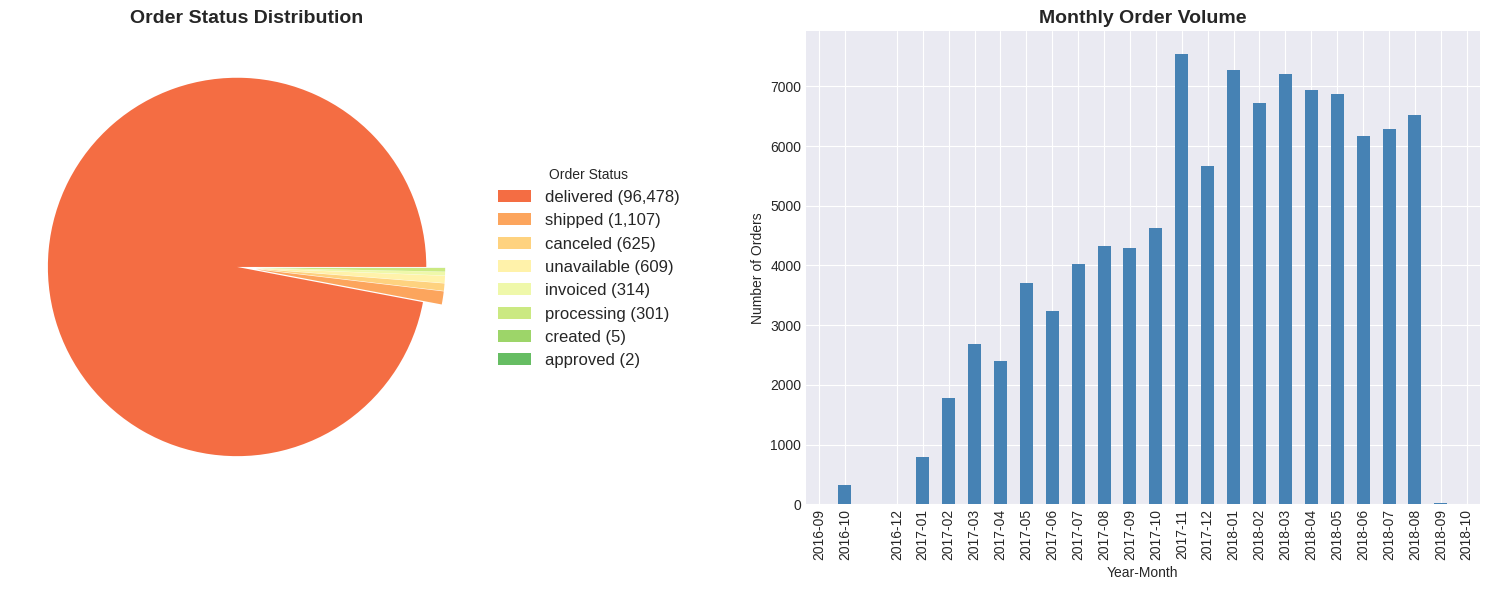

Total Orders: 99,441
Delivered: 96,478 (97.0%)
Canceled: 625 (0.6%)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Order status distribution
order_status = orders['order_status'].value_counts()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(order_status)))

# Create pie chart and capture wedges for legend
wedges, texts = axes[0].pie(
    order_status.values,
    colors=colors, 
    explode=[0.05]*len(order_status)
)


# Add legend with values and percentages
legend_labels = [f'{label} ({value:,})' 
                 for label, value in zip(order_status.index, order_status.values)]
axes[0].legend(wedges, legend_labels, 
               title="Order Status",
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1),
               fontsize=12)
axes[0].set_title('Order Status Distribution', fontsize=14, fontweight='bold')

# Monthly order trend
monthly_orders = orders.groupby('purchase_year_month').size()
monthly_orders.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Monthly Order Volume', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year-Month')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

print(f"Total Orders: {len(orders):,}")
print(f"Delivered: {len(orders[orders['order_status']=='delivered']):,} ({len(orders[orders['order_status']=='delivered'])/len(orders)*100:.1f}%)")
print(f"Canceled: {len(orders[orders['order_status']=='canceled']):,} ({len(orders[orders['order_status']=='canceled'])/len(orders)*100:.1f}%)")

### 4.2 Purchase Patterns Analysis

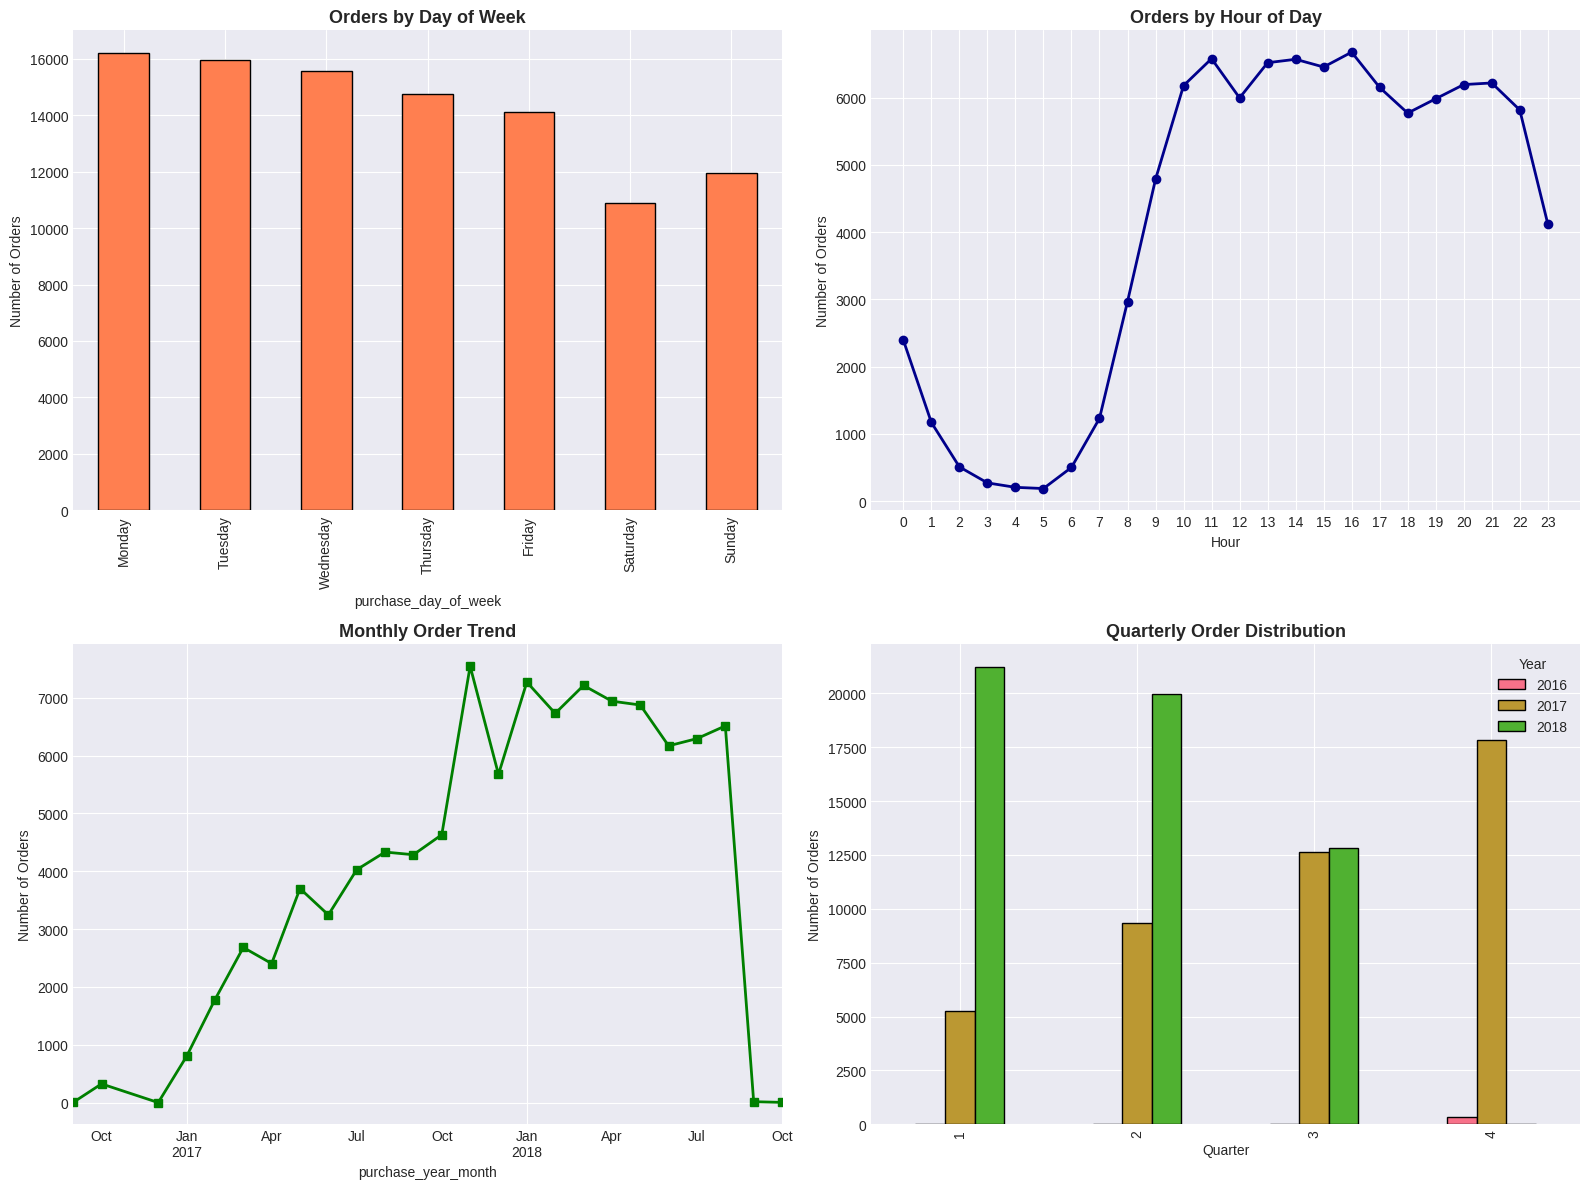

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Orders by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = orders['purchase_day_of_week'].value_counts().reindex(day_order)
day_counts.plot(kind='bar', ax=axes[0,0], color='coral', edgecolor='black')
axes[0,0].set_title('Orders by Day of Week', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Number of Orders')

# Orders by hour of day
hour_counts = orders['purchase_hour'].value_counts().sort_index()
hour_counts.plot(kind='line', marker='o', ax=axes[0,1], color='darkblue', linewidth=2)
axes[0,1].set_title('Orders by Hour of Day', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].set_xticks(range(24))
axes[0,1].set_xticklabels(range(24))

# Monthly order trend (line plot)
monthly_orders.plot(kind='line', marker='s', ax=axes[1,0], color='green', linewidth=2)
axes[1,0].set_title('Monthly Order Trend', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Number of Orders')

# Quarterly analysis
orders['quarter'] = orders['order_purchase_timestamp'].dt.quarter
quarterly_orders = orders.groupby(['purchase_year', 'quarter']).size().unstack(level=0)
quarterly_orders.plot(kind='bar', ax=axes[1,1], edgecolor='black')
axes[1,1].set_title('Quarterly Order Distribution', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Quarter')
axes[1,1].set_ylabel('Number of Orders')
axes[1,1].legend(title='Year')

plt.tight_layout()
plt.show()

## 5. Business Analysis <a class="anchor" id="5-business-analysis"></a>
### 5.1 Sales & Revenue Analysis

In [32]:
# Revenue metrics
total_revenue = master_df['price'].sum()
total_freight = master_df['freight_value'].sum()
avg_order_value = master_df.groupby('order_id')['price'].sum().mean()

print("=" * 60)
print("-- REVENUE METRICS")
print("=" * 60)
print(f"Total Revenue (Product Value):   R$ {total_revenue:,.2f}")
print(f"Total Freight Revenue:           R$ {total_freight:,.2f}")
print(f"Total Revenue (All):             R$ {total_revenue + total_freight:,.2f}")
print(f"Average Order Value (AOV):       R$ {avg_order_value:,.2f}")
print(f"Average Items per Order:         {len(order_items)/len(orders):.2f}")

-- REVENUE METRICS
Total Revenue (Product Value):   R$ 13,651,923.47
Total Freight Revenue:           R$ 2,263,948.85
Total Revenue (All):             R$ 15,915,872.32
Average Order Value (AOV):       R$ 137.29
Average Items per Order:         1.13


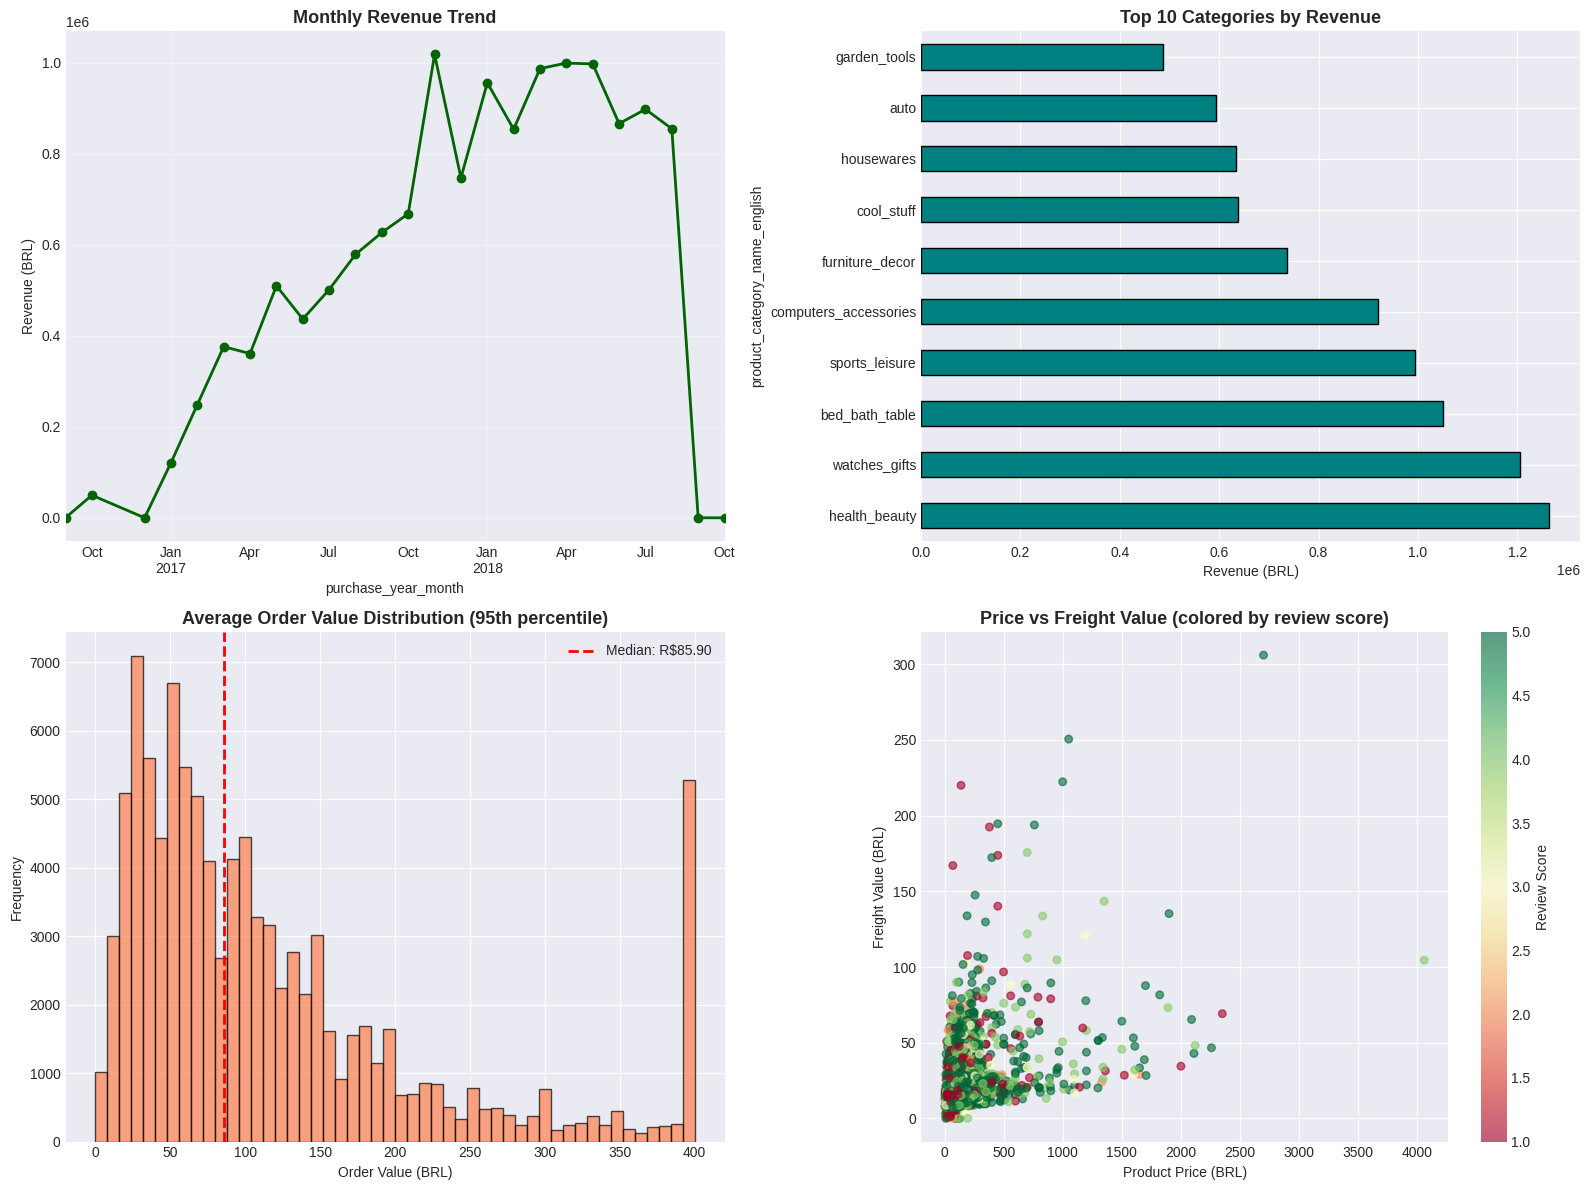

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Monthly revenue trend
monthly_revenue = master_df.groupby('purchase_year_month')['price'].sum()
monthly_revenue.plot(kind='line', marker='o', ax=axes[0,0], color='darkgreen', linewidth=2)
axes[0,0].set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Revenue (BRL)')
axes[0,0].grid(True, alpha=0.3)

# Revenue by product category (Top 10)
category_revenue = master_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
category_revenue.plot(kind='barh', ax=axes[0,1], color='teal', edgecolor='black')
axes[0,1].set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Revenue (BRL)')

# Average order value distribution
aov_by_order = master_df.groupby('order_id')['price'].sum()
axes[1,0].hist(aov_by_order.clip(upper=aov_by_order.quantile(0.95)), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1,0].axvline(aov_by_order.median(), color='red', linestyle='--', linewidth=2, label=f'Median: R${aov_by_order.median():.2f}')
axes[1,0].set_title('Average Order Value Distribution (95th percentile)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Order Value (BRL)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Revenue vs Freight scatter
sample_df = master_df.sample(5000)
scatter = axes[1,1].scatter(sample_df['price'], sample_df['freight_value'], c=sample_df['review_score'], cmap='RdYlGn', alpha=0.6, s=30)
axes[1,1].set_title('Price vs Freight Value (colored by review score)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Product Price (BRL)')
axes[1,1].set_ylabel('Freight Value (BRL)')
plt.colorbar(scatter, ax=axes[1,1], label='Review Score')

plt.tight_layout()
plt.show()

### 5.2 Customer Analysis

In [15]:
# Customer metrics
unique_customers = customers['customer_unique_id'].nunique()
repeat_customers = customers.groupby('customer_unique_id').filter(lambda x: len(x) > 1)['customer_unique_id'].nunique()
avg_orders_per_customer = len(orders) / unique_customers

print("=" * 60)
print("-- CUSTOMER METRICS")
print("=" * 60)
print(f"Total Customer IDs:              {len(customers):,}")
print(f"Unique Customers:                {unique_customers:,}")
print(f"Repeat Customers:                {repeat_customers:,} ({repeat_customers/unique_customers*100:.2f}%)")
print(f"Average Orders per Customer:     {avg_orders_per_customer:.2f}")

👤 CUSTOMER METRICS
Total Customer IDs:             99,441
Unique Customers:                96,096
Repeat Customers:                2,997 (3.12%)
Average Orders per Customer:     1.03


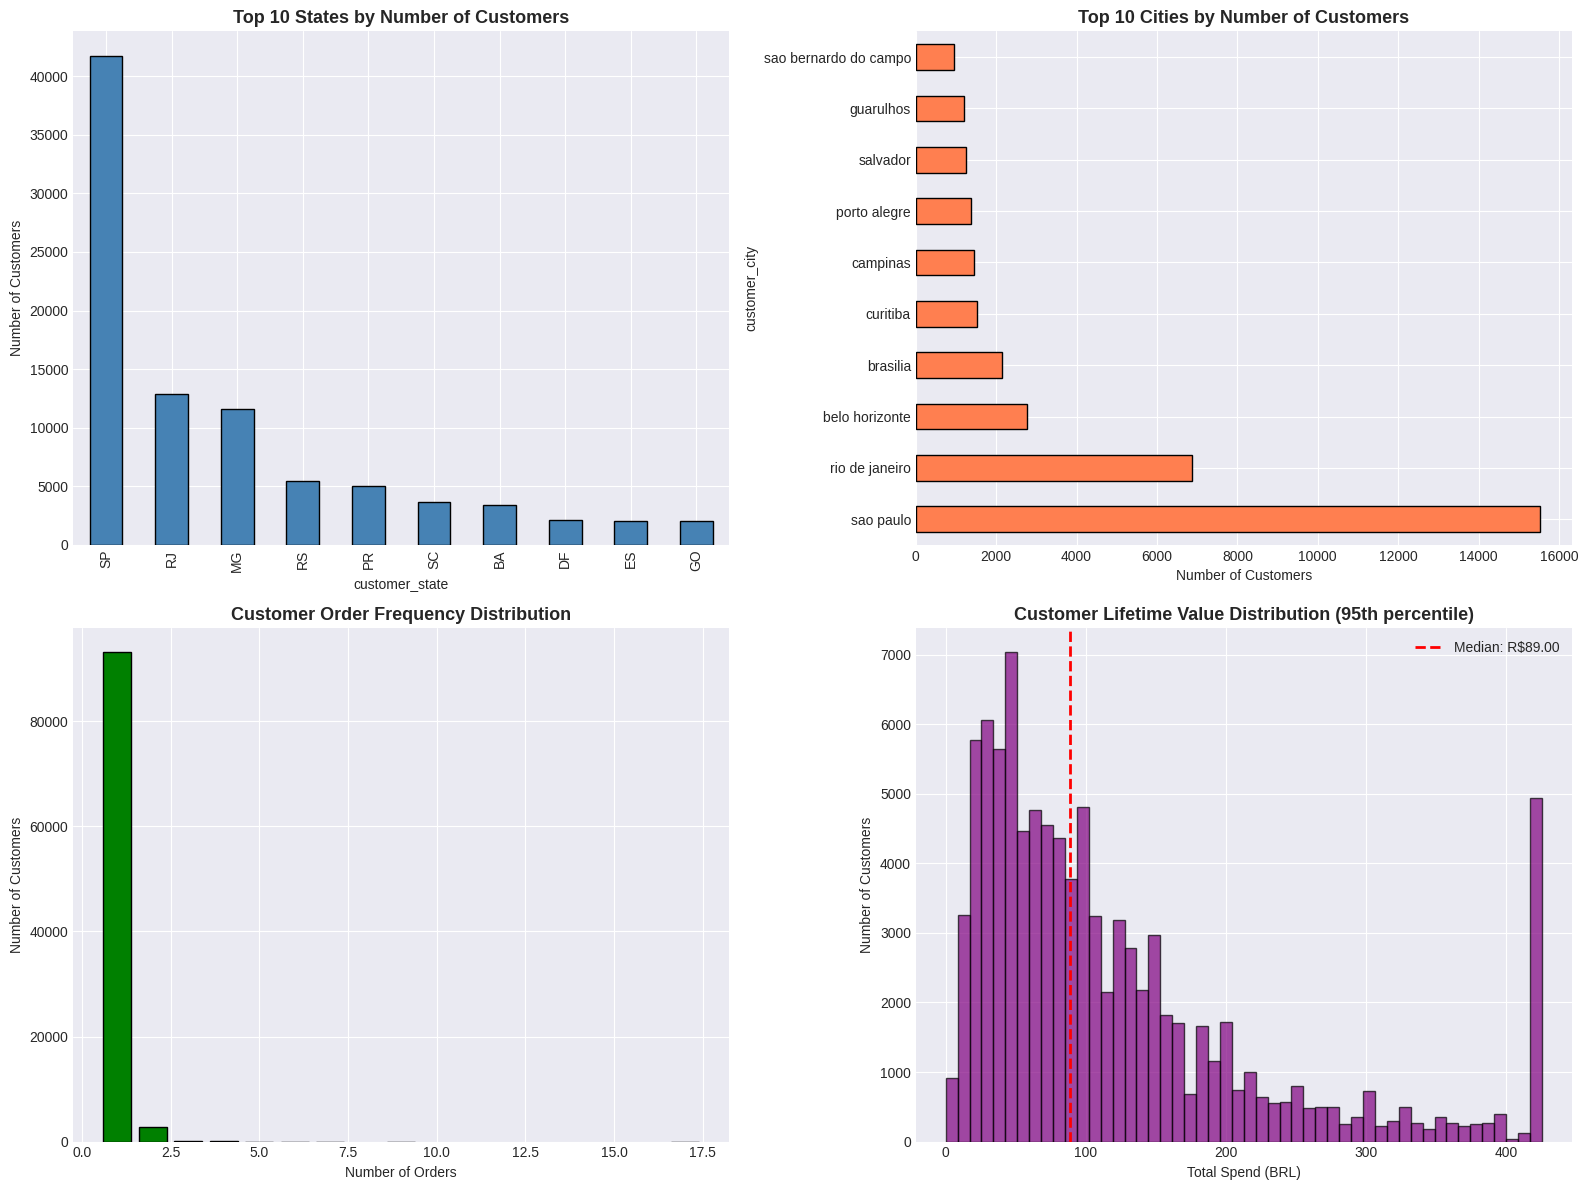


📊 CLV Statistics:
  - Mean CLV:   R$ 142.07
  - Median CLV: R$ 89.00
  - Max CLV:    R$ 13440.00


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 states by customers
state_counts = customers['customer_state'].value_counts().head(10)
state_counts.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Top 10 States by Number of Customers', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Number of Customers')

# Top 10 cities by customers
city_counts = customers['customer_city'].value_counts().head(10)
city_counts.plot(kind='barh', ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Top 10 Cities by Number of Customers', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Number of Customers')

# Customer order frequency distribution
orders_per_customer = customers.groupby('customer_unique_id').size()
order_freq = orders_per_customer.value_counts().sort_index()
axes[1,0].bar(order_freq.index[:10], order_freq.values[:10], color='green', edgecolor='black')
axes[1,0].set_title('Customer Order Frequency Distribution', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Number of Orders')
axes[1,0].set_ylabel('Number of Customers')

# Customer Lifetime Value (CLV) distribution
clv = master_df.groupby('customer_unique_id')['price'].sum()
axes[1,1].hist(clv.clip(upper=clv.quantile(0.95)), bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1,1].axvline(clv.median(), color='red', linestyle='--', linewidth=2, label=f'Median: R${clv.median():.2f}')
axes[1,1].set_title('Customer Lifetime Value Distribution (95th percentile)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Total Spend (BRL)')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f"\n📊 CLV Statistics:")
print(f"  - Mean CLV:   R$ {clv.mean():.2f}")
print(f"  - Median CLV: R$ {clv.median():.2f}")
print(f"  - Max CLV:    R$ {clv.max():.2f}")

### 5.3 Seller Analysis

In [17]:
# Seller performance metrics
seller_revenue = master_df.groupby(['seller_id', 'seller_state'])['price'].sum().reset_index()
seller_orders = master_df.groupby('seller_id')['order_id'].nunique()
seller_avg_review = master_df.groupby('seller_id')['review_score'].mean()

print("=" * 60)
print("🏪 SELLER METRICS")
print("=" * 60)
print(f"Total Sellers:                   {len(sellers):,}")
print(f"Average Orders per Seller:       {seller_orders.mean():.2f}")
print(f"Median Orders per Seller:        {seller_orders.median():.2f}")
print(f"Average Revenue per Seller:      R$ {seller_revenue['price'].mean():.2f}")
print(f"Average Review Score:            {seller_avg_review.mean():.2f} / 5.00")
print(f"\nTop 5 Sellers by Revenue:")
display(seller_revenue.nlargest(5, 'price')[['seller_id', 'seller_state', 'price']])

🏪 SELLER METRICS
Total Sellers:                   3,095
Average Orders per Seller:       32.31
Median Orders per Seller:        6.00
Average Revenue per Seller:      R$ 4410.96
Average Review Score:            3.97 / 5.00

Top 5 Sellers by Revenue:


,seller_id,seller_state,price
857,4869f7a5dfa277a7dca6462dcf3b52b2,SP,229472.63
1013,53243585a1d6dc2643021fd1853d8905,BA,222776.05
881,4a3ca9315b744ce9f8e9374361493884,SP,202999.12
3024,fa1c13f2614d7b5c4749cbc52fecda94,SP,194042.03
1535,7c67e1448b00f6e969d365cea6b010ab,SP,189417.67


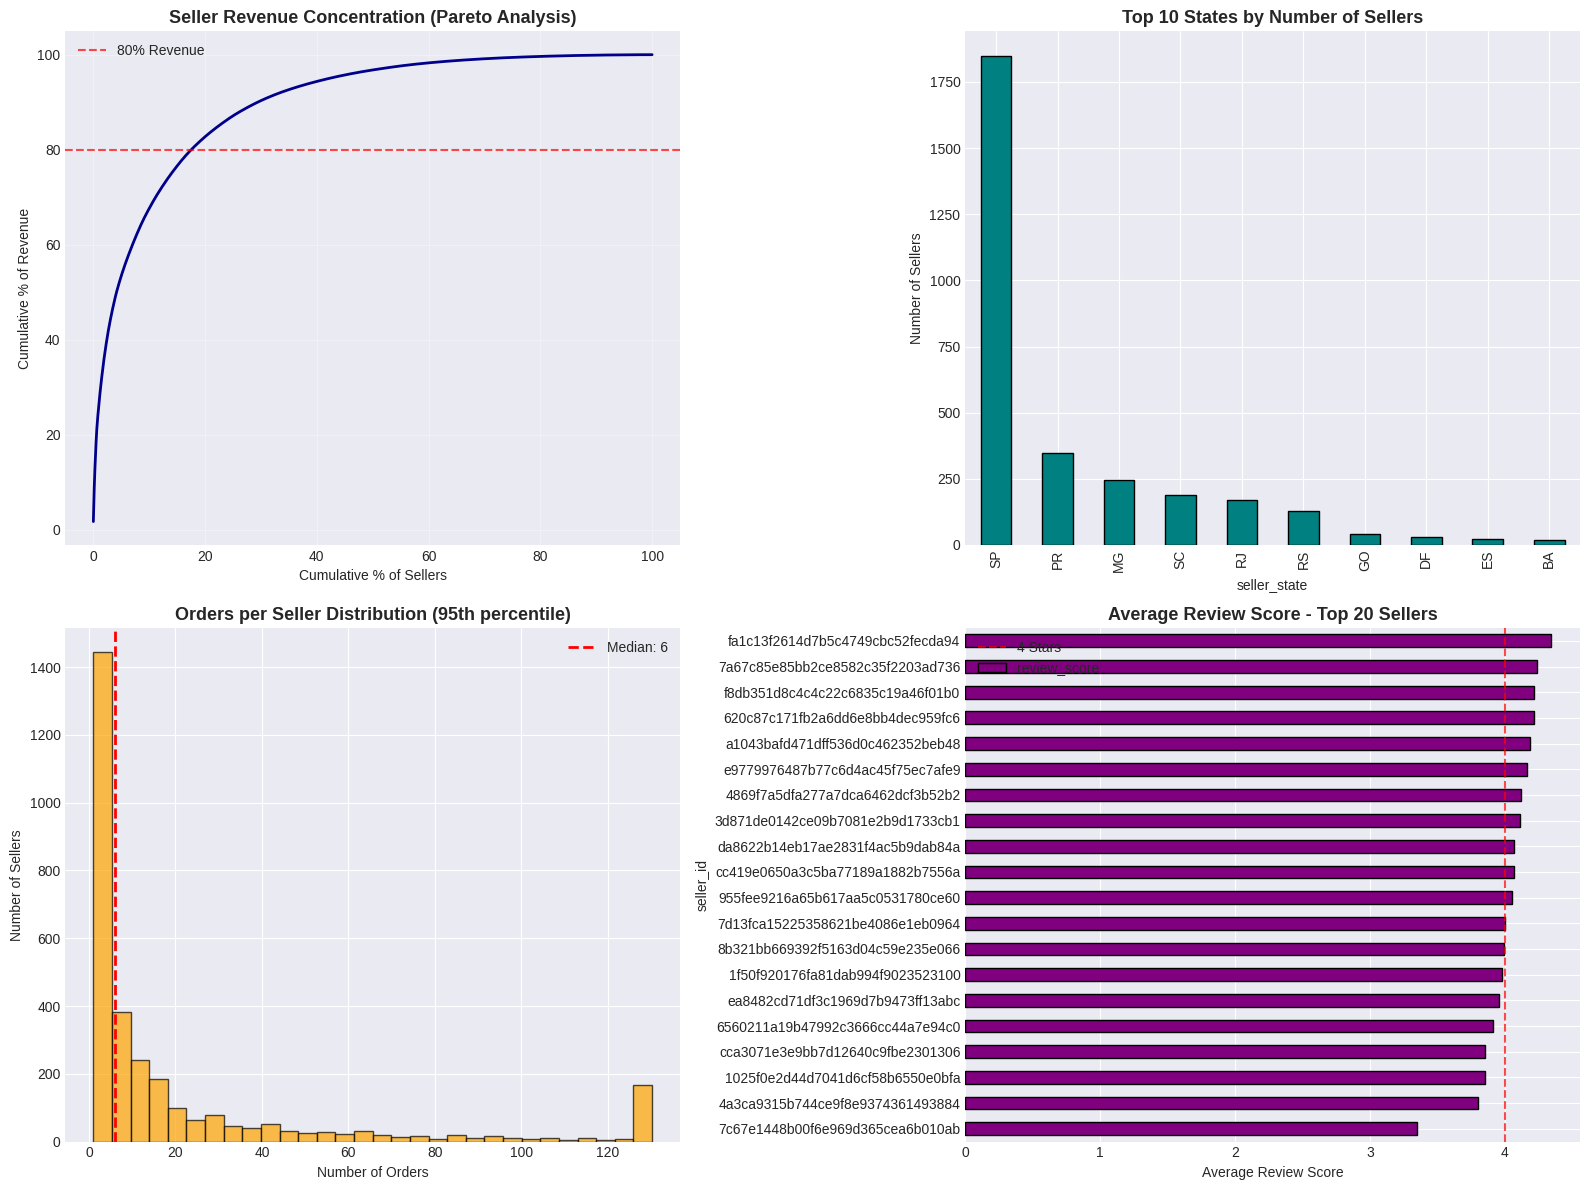

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Seller concentration (Pareto principle)
seller_revenue_sorted = seller_revenue['price'].sort_values(ascending=False)
cumulative_revenue = seller_revenue_sorted.cumsum() / seller_revenue_sorted.sum() * 100
cumulative_sellers = np.arange(1, len(seller_revenue_sorted)+1) / len(seller_revenue_sorted) * 100

axes[0,0].plot(cumulative_sellers, cumulative_revenue, linewidth=2, color='darkblue')
axes[0,0].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% Revenue')
axes[0,0].set_title('Seller Revenue Concentration (Pareto Analysis)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Cumulative % of Sellers')
axes[0,0].set_ylabel('Cumulative % of Revenue')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Sellers by state
seller_state_counts = sellers['seller_state'].value_counts().head(10)
seller_state_counts.plot(kind='bar', ax=axes[0,1], color='teal', edgecolor='black')
axes[0,1].set_title('Top 10 States by Number of Sellers', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Number of Sellers')

# Orders per seller distribution
axes[1,0].hist(seller_orders.clip(upper=seller_orders.quantile(0.95)), bins=30, 
               color='orange', edgecolor='black', alpha=0.7)
axes[1,0].axvline(seller_orders.median(), color='red', linestyle='--', linewidth=2, 
                  label=f'Median: {seller_orders.median():.0f}')
axes[1,0].set_title('Orders per Seller Distribution (95th percentile)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Number of Orders')
axes[1,0].set_ylabel('Number of Sellers')
axes[1,0].legend()

# Average review score by seller (Top 20 sellers by order count)
top_sellers = seller_orders.nlargest(20).index
top_seller_reviews = seller_avg_review[top_sellers].sort_values()
top_seller_reviews.plot(kind='barh', ax=axes[1,1], color='purple', edgecolor='black')
axes[1,1].axvline(x=4.0, color='red', linestyle='--', alpha=0.7, label='4 Stars')
axes[1,1].set_title('Average Review Score - Top 20 Sellers', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Average Review Score')
axes[1,1].legend()

plt.tight_layout()
plt.show()

### 5.4 Product Analysis

In [19]:
# Product category analysis
category_stats = master_df.groupby('product_category_name_english').agg({
    'price': ['count', 'sum', 'mean', 'std'],
    'review_score': 'mean',
    'freight_value': 'mean'
}).round(2)

category_stats.columns = ['Total Orders', 'Total Revenue', 'Avg Price', 'Price Std', 'Avg Review', 'Avg Freight']
category_stats = category_stats.sort_values('Total Orders', ascending=False)

print("=" * 80)
print("📦 TOP 10 PRODUCT CATEGORIES")
print("=" * 80)
display(category_stats.head(10))

📦 TOP 10 PRODUCT CATEGORIES


,Total Orders,Total Revenue,Avg Price,Price Std,Avg Review,Avg Freight
product_category_name_english,,,,,,
bed_bath_table,11270,1050936.61,93.25,81.89,3.90,18.39
health_beauty,9727,1263138.54,129.86,179.15,4.14,18.86
sports_leisure,8700,993656.51,114.21,162.04,4.11,19.50
furniture_decor,8415,736282.47,87.50,88.66,3.90,20.72
computers_accessories,7894,919640.54,116.50,169.43,3.93,18.80
housewares,6989,634542.60,90.79,141.88,4.06,20.98
watches_gifts,6001,1206075.33,200.98,256.65,4.02,16.78
telephony,4550,323839.40,71.17,135.70,3.95,15.68
garden_tools,4361,486432.45,111.54,200.34,4.04,22.75


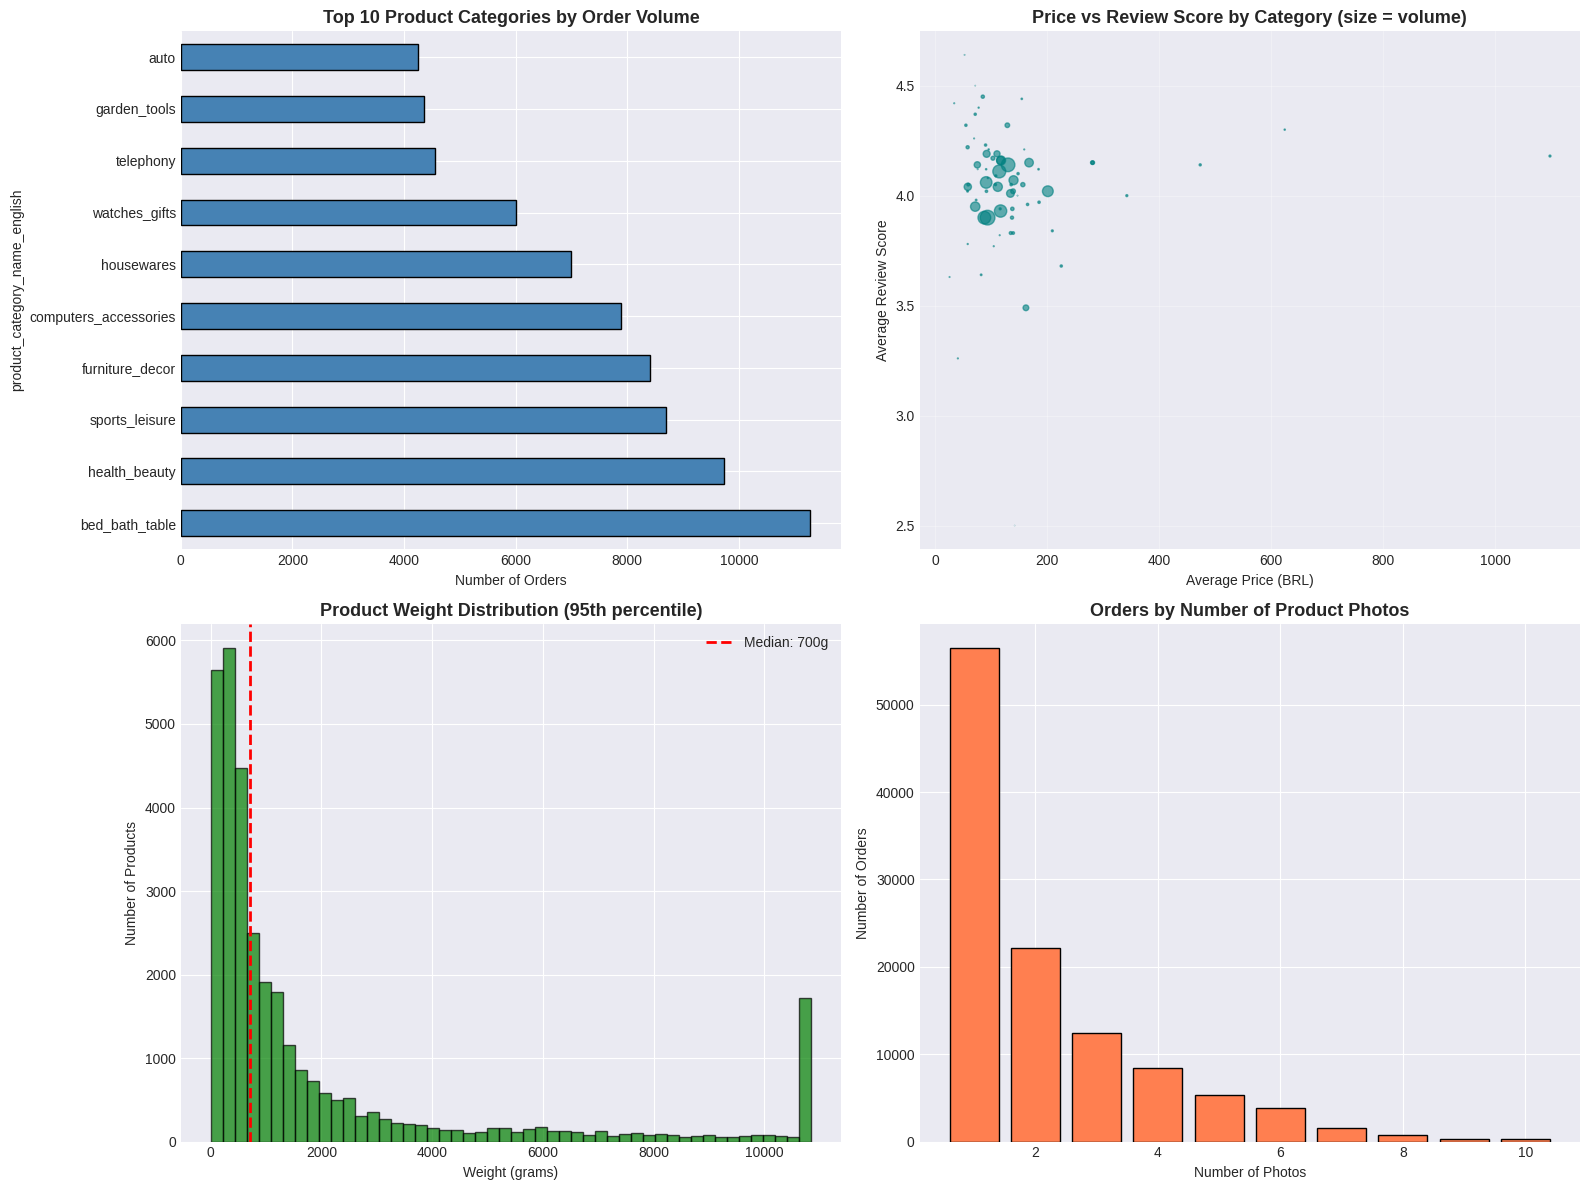

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 categories by order volume
top_categories = category_stats.head(10)
top_categories['Total Orders'].plot(kind='barh', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Top 10 Product Categories by Order Volume', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Number of Orders')

# Price vs Review Score by category
axes[0,1].scatter(category_stats['Avg Price'], category_stats['Avg Review'], 
                  s=category_stats['Total Orders']/100, alpha=0.6, c='teal')
axes[0,1].set_title('Price vs Review Score by Category (size = volume)', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Average Price (BRL)')
axes[0,1].set_ylabel('Average Review Score')
axes[0,1].grid(True, alpha=0.3)

# Product weight distribution
weights = products['product_weight_g'].dropna()
axes[1,0].hist(weights.clip(upper=weights.quantile(0.95)), bins=50, 
               color='green', edgecolor='black', alpha=0.7)
axes[1,0].axvline(weights.median(), color='red', linestyle='--', linewidth=2, 
                  label=f'Median: {weights.median():.0f}g')
axes[1,0].set_title('Product Weight Distribution (95th percentile)', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Weight (grams)')
axes[1,0].set_ylabel('Number of Products')
axes[1,0].legend()

# Product photos quantity vs sales (correlation)
photo_sales = master_df.groupby('product_photos_qty').agg({
    'order_id': 'count',
    'price': 'mean'
})
axes[1,1].bar(photo_sales.index[:10], photo_sales['order_id'].values[:10], 
              color='coral', edgecolor='black')
axes[1,1].set_title('Orders by Number of Product Photos', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Number of Photos')
axes[1,1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

### 5.5 Delivery & Logistics Analysis

In [21]:
# Delivery performance metrics
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
on_time = len(delivered_orders[delivered_orders['delivery_delay'] <= 0])
late = len(delivered_orders[delivered_orders['delivery_delay'] > 0])

print("=" * 60)
print("🚚 DELIVERY PERFORMANCE")
print("=" * 60)
print(f"On-Time Deliveries:      {on_time:,} ({on_time/len(delivered_orders)*100:.2f}%)")
print(f"Late Deliveries:         {late:,} ({late/len(delivered_orders)*100:.2f}%)")
print(f"Average Delivery Time:   {delivered_orders['delivery_time_days'].mean():.2f} days")
print(f"Median Delivery Time:    {delivered_orders['delivery_time_days'].median():.2f} days")
print(f"Average Delay (if late): {delivered_orders[delivered_orders['delivery_delay']>0]['delivery_delay'].mean():.2f} days")

🚚 DELIVERY PERFORMANCE
On-Time Deliveries:      89,936 (93.22%)
Late Deliveries:         6,534 (6.77%)
Average Delivery Time:   12.09 days
Median Delivery Time:    10.00 days
Average Delay (if late): 10.62 days


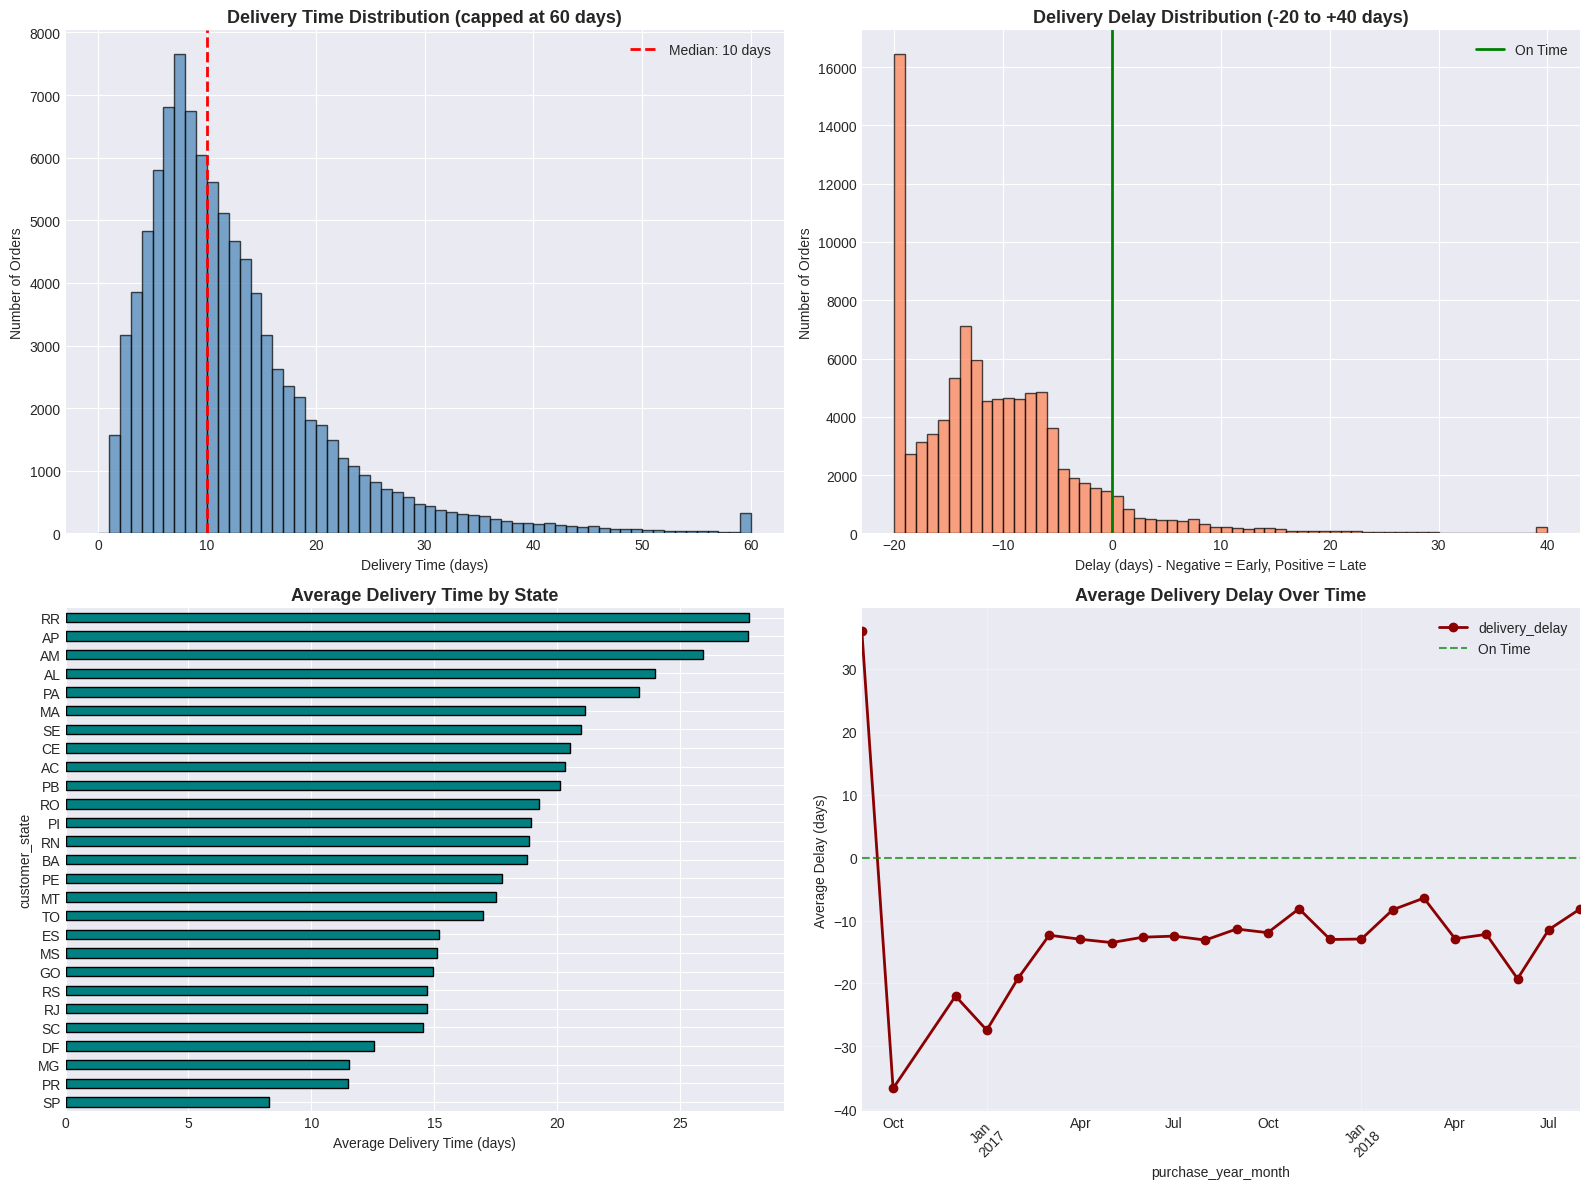

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Delivery time distribution
axes[0,0].hist(delivered_orders['delivery_time_days'].clip(upper=60), bins=60, 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(delivered_orders['delivery_time_days'].median(), color='red', 
                  linestyle='--', linewidth=2, label=f'Median: {delivered_orders["delivery_time_days"].median():.0f} days')
axes[0,0].set_title('Delivery Time Distribution (capped at 60 days)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Delivery Time (days)')
axes[0,0].set_ylabel('Number of Orders')
axes[0,0].legend()

# Delivery delay distribution
axes[0,1].hist(delivered_orders['delivery_delay'].clip(lower=-20, upper=40), bins=60, 
               color='coral', edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0, color='green', linestyle='-', linewidth=2, label='On Time')
axes[0,1].set_title('Delivery Delay Distribution (-20 to +40 days)', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Delay (days) - Negative = Early, Positive = Late')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].legend()

# Delivery time by state
state_delivery = master_df[master_df['order_status']=='delivered'].groupby('customer_state')['delivery_time_days'].mean().sort_values()
state_delivery.plot(kind='barh', ax=axes[1,0], color='teal', edgecolor='black')
axes[1,0].set_title('Average Delivery Time by State', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Average Delivery Time (days)')

# Delivery delay over time
monthly_delay = delivered_orders.groupby('purchase_year_month')['delivery_delay'].mean()
monthly_delay.plot(kind='line', marker='o', ax=axes[1,1], color='darkred', linewidth=2)
axes[1,1].axhline(y=0, color='green', linestyle='--', alpha=0.7, label='On Time')
axes[1,1].set_title('Average Delivery Delay Over Time', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Average Delay (days)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.6 Payment Analysis

In [23]:
# Payment method analysis
payment_type_counts = order_payments['payment_type'].value_counts()
payment_avg_value = order_payments.groupby('payment_type')['payment_value'].mean()
payment_total_value = order_payments.groupby('payment_type')['payment_value'].sum()

payment_summary = pd.DataFrame({
    'Transaction Count': payment_type_counts,
    'Percentage (%)': (payment_type_counts / len(order_payments) * 100).round(2),
    'Avg Transaction Value (BRL)': payment_avg_value.round(2),
    'Total Value (BRL)': payment_total_value.round(2)
})

print("=" * 80)
print("💳 PAYMENT METHOD SUMMARY")
print("=" * 80)
display(payment_summary)

💳 PAYMENT METHOD SUMMARY


,Transaction Count,Percentage (%),Avg Transaction Value (BRL),Total Value (BRL)
payment_type,,,,
boleto,19784,19.04,145.03,2869361.27
credit_card,76795,73.92,163.32,12542084.19
debit_card,1529,1.47,142.57,217989.79
not_defined,3,0.00,0.00,0.00
voucher,5775,5.56,65.70,379436.87


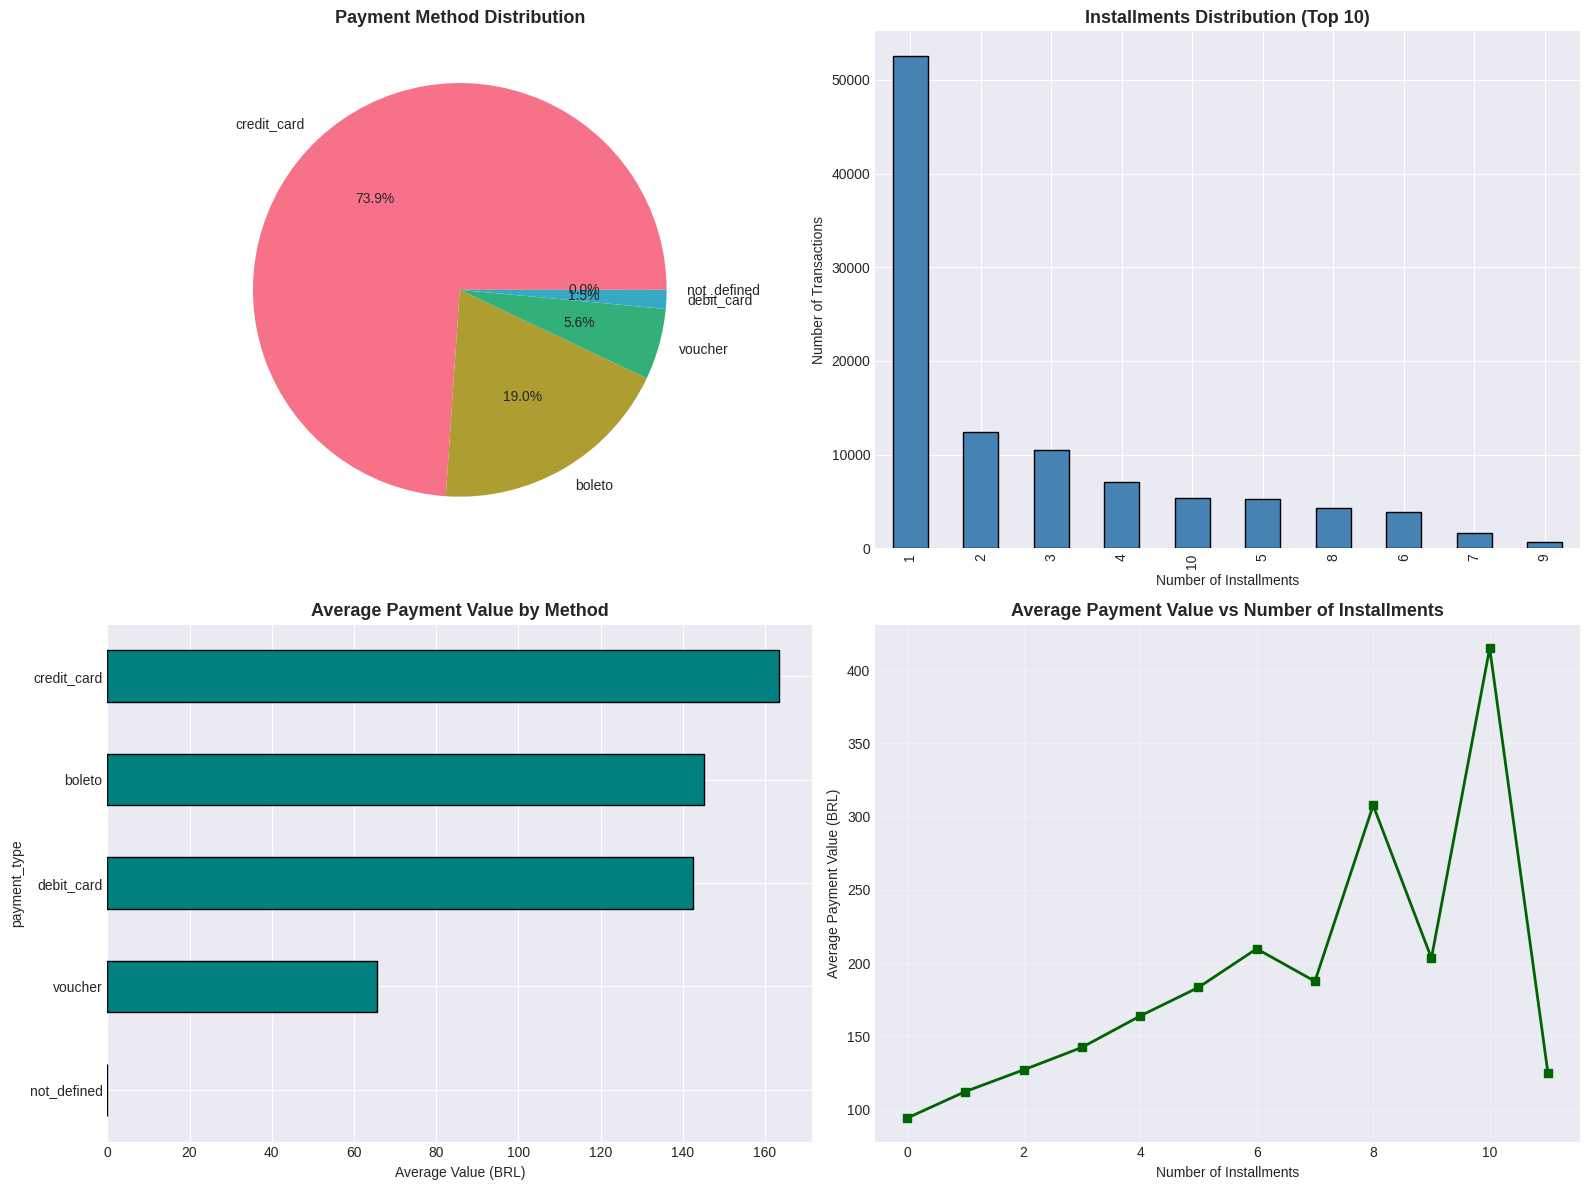

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Payment type distribution
payment_type_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[0,0], 
                          colors=sns.color_palette('husl', 5))
axes[0,0].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('')

# Installments distribution
installments = order_payments['payment_installments'].value_counts().head(10)
installments.plot(kind='bar', ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Installments Distribution (Top 10)', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Number of Installments')
axes[0,1].set_ylabel('Number of Transactions')

# Average payment value by payment type
payment_avg_value.sort_values().plot(kind='barh', ax=axes[1,0], color='teal', edgecolor='black')
axes[1,0].set_title('Average Payment Value by Method', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Average Value (BRL)')

# Installments vs Payment Value
avg_value_by_installments = order_payments.groupby('payment_installments')['payment_value'].mean()
axes[1,1].plot(avg_value_by_installments.index[:12], avg_value_by_installments.values[:12], 
              marker='s', linewidth=2, color='darkgreen')
axes[1,1].set_title('Average Payment Value vs Number of Installments', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Number of Installments')
axes[1,1].set_ylabel('Average Payment Value (BRL)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.7 Review & Satisfaction Analysis

In [25]:
# Review metrics
avg_review = order_reviews['review_score'].mean()
review_dist = order_reviews['review_score'].value_counts().sort_index()
positive_reviews = len(order_reviews[order_reviews['review_score'] >= 4])

print("=" * 60)
print("⭐ REVIEW & SATISFACTION METRICS")
print("=" * 60)
print(f"Total Reviews:            {len(order_reviews):,}")
print(f"Average Review Score:     {avg_review:.2f} / 5.00")
print(f"Positive Reviews (≥4):    {positive_reviews:,} ({positive_reviews/len(order_reviews)*100:.1f}%)")
print(f"\nReview Score Distribution:")
for score, count in review_dist.items():
    print(f"  {score} Stars: {count:>6,} ({count/len(order_reviews)*100:>5.1f}%)")

⭐ REVIEW & SATISFACTION METRICS
Total Reviews:            99,224
Average Review Score:     4.09 / 5.00
Positive Reviews (≥4):    76,470 (77.1%)

Review Score Distribution:
  1 Stars: 11,424 ( 11.5%)
  2 Stars:  3,151 (  3.2%)
  3 Stars:  8,179 (  8.2%)
  4 Stars: 19,142 ( 19.3%)
  5 Stars: 57,328 ( 57.8%)


KeyError: 'delivery_time_bin'

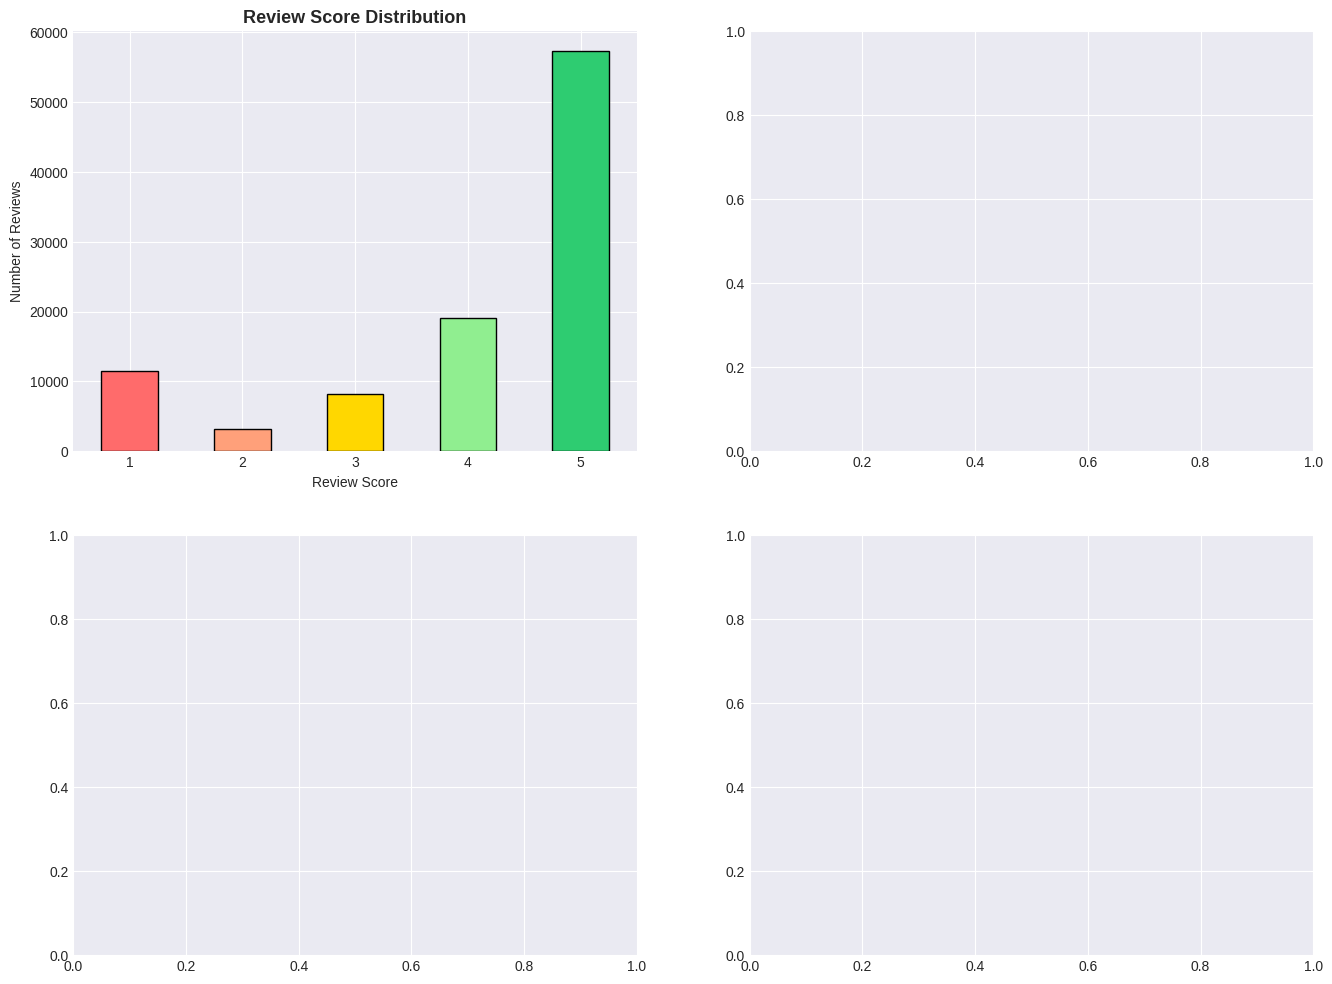

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Review score distribution
review_dist.plot(kind='bar', ax=axes[0,0], color=['#FF6B6B', '#FFA07A', '#FFD700', '#90EE90', '#2ECC71'], edgecolor='black')
axes[0,0].set_title('Review Score Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Review Score')
axes[0,0].set_ylabel('Number of Reviews')
axes[0,0].tick_params(axis='x', rotation=0)

# Review score vs delivery time
delivered_orders['delivery_time_bin'] = pd.cut(delivered_orders['delivery_time_days'], bins=[0,3,5,7,10,15,20,30,100])
review_by_delivery = master_df[master_df['order_status']=='delivered'].groupby('delivery_time_bin')['review_score'].mean()
review_by_delivery.plot(kind='bar', ax=axes[0,1], color='teal', edgecolor='black')
axes[0,1].set_title('Average Review Score by Delivery Time', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Delivery Time (days)')
axes[0,1].set_ylabel('Average Review Score')
axes[0,1].tick_params(axis='x', rotation=45)

# Review score vs price
price_bins = pd.cut(master_df['price'], bins=[0,50,100,200,500,1000,10000])
review_by_price = master_df.groupby(price_bins)['review_score'].mean()
review_by_price.plot(kind='bar', ax=axes[1,0], color='coral', edgecolor='black')
axes[1,0].set_title('Average Review Score by Price Range', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Price Range (BRL)')
axes[1,0].set_ylabel('Average Review Score')
axes[1,0].tick_params(axis='x', rotation=45)

# Review response time analysis
order_reviews['response_time_hours'] = (order_reviews['review_answer_timestamp'] - order_reviews['review_creation_date']).dt.total_seconds() / 3600
response_time_clean = order_reviews['response_time_hours'].clip(upper=order_reviews['response_time_hours'].quantile(0.95))
axes[1,1].hist(response_time_clean, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1,1].axvline(order_reviews['response_time_hours'].median(), color='red', linestyle='--', linewidth=2, 
                  label=f'Median: {order_reviews["response_time_hours"].median():.1f} hours')
axes[1,1].set_title('Review Response Time Distribution (95th percentile)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Response Time (hours)')
axes[1,1].set_ylabel('Number of Reviews')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 6. Advanced Analysis <a class="anchor" id="6-advanced-analysis"></a>

CORRELATION ANALYSIS


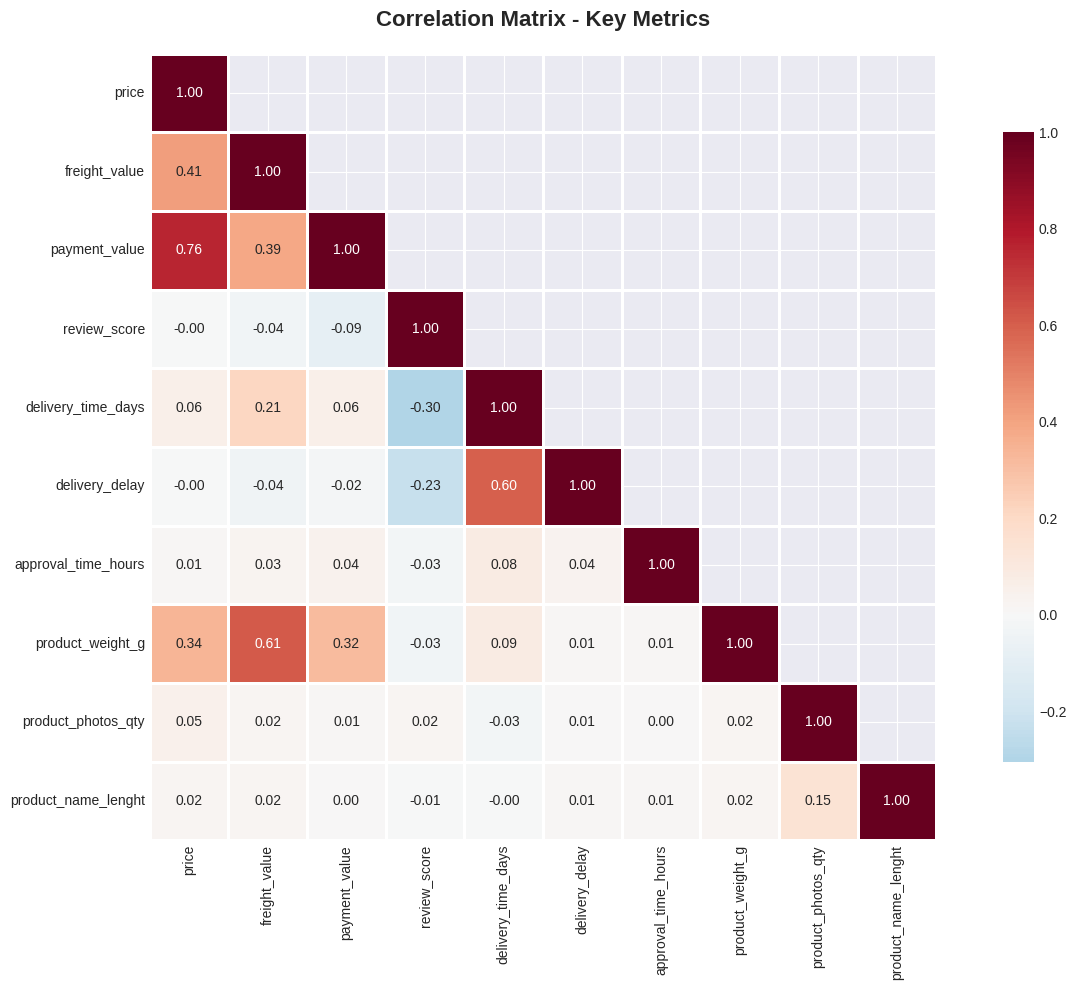

  delivery_delay vs review_score: -0.229
  price vs freight_value: 0.414
  price vs review_score: -0.004
  product_photos_qty vs review_score: 0.023


In [27]:
# Correlation Analysis
print("CORRELATION ANALYSIS")
print("=" * 60)

correlation_cols = [
    'price', 'freight_value', 'payment_value', 'review_score',
    'delivery_time_days', 'delivery_delay', 'approval_time_hours',
    'product_weight_g', 'product_photos_qty', 'product_name_lenght'
]

correlation_df = master_df[correlation_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_df, dtype=bool), k=1)
sns.heatmap(correlation_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})
plt.title('Correlation Matrix - Key Metrics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Key correlations
correlations_to_check = [
    ('delivery_delay', 'review_score'),
    ('price', 'freight_value'),
    ('price', 'review_score'),
    ('product_photos_qty', 'review_score')
]

for col1, col2 in correlations_to_check:
    corr = master_df[col1].corr(master_df[col2])
    print(f"  {col1} vs {col2}: {corr:.3f}")

CUSTOMER SEGMENTATION (RFM Analysis)
RFM Summary:
  Average Recency:          291 days
  Average Frequency:        1.00 orders
  Average Monetary Value:   R$ 137.29


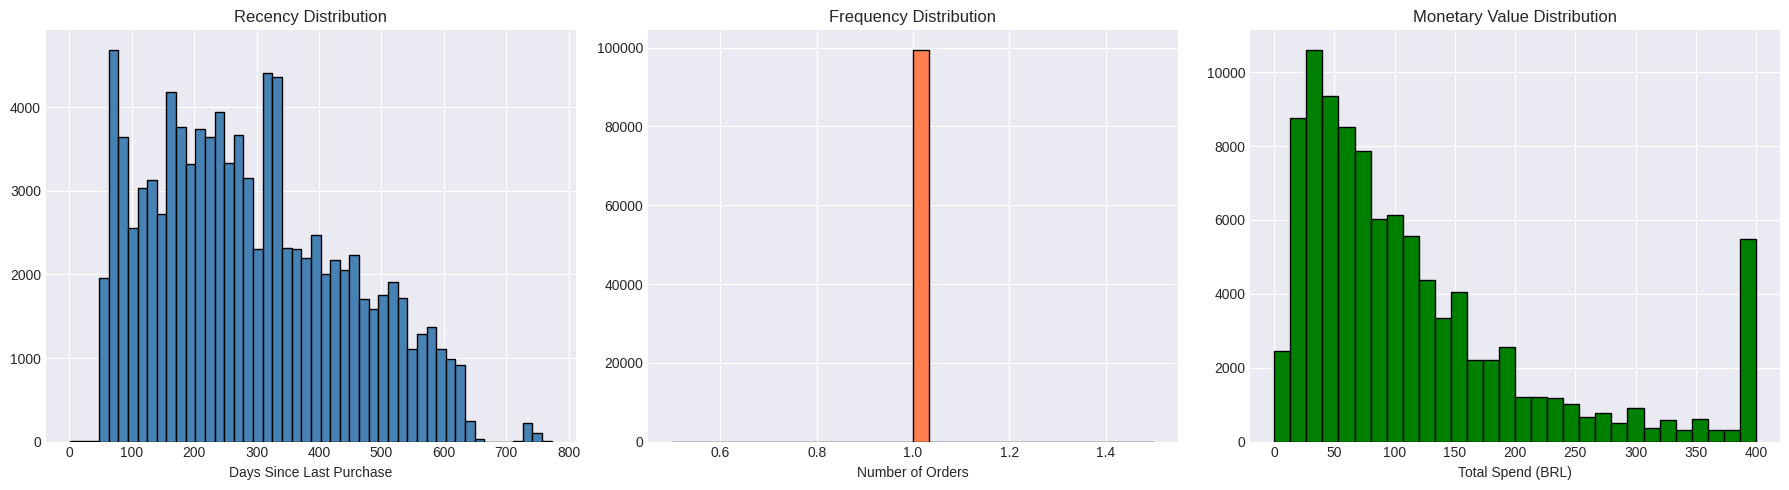

In [28]:
# Customer Segmentation (RFM Analysis)
print("CUSTOMER SEGMENTATION (RFM Analysis)")
print("=" * 60)

reference_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'count',  # Frequency
    'delivery_time_days': 'mean'  # Monetary proxy
}).rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'delivery_time_days': 'avg_delivery_time'
})

# Add monetary value
monetary = master_df.groupby('customer_id')['price'].sum()
rfm['monetary'] = monetary

print(f"RFM Summary:")
print(f"  Average Recency:          {rfm['recency'].mean():.0f} days")
print(f"  Average Frequency:        {rfm['frequency'].mean():.2f} orders")
print(f"  Average Monetary Value:   R$ {rfm['monetary'].mean():.2f}")

# Visualize RFM segments
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['recency'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

axes[1].hist(rfm['frequency'].clip(upper=rfm['frequency'].quantile(0.95)), bins=30, color='coral', edgecolor='black')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Orders')

axes[2].hist(rfm['monetary'].clip(upper=rfm['monetary'].quantile(0.95)), bins=30, color='green', edgecolor='black')
axes[2].set_title('Monetary Value Distribution')
axes[2].set_xlabel('Total Spend (BRL)')

plt.tight_layout()
plt.show()

In [29]:
# Cohort Analysis
print("COHORT ANALYSIS - Customer Retention")
print("=" * 60)

# Create cohort by first purchase month
customer_first_purchase = orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
customer_first_purchase.columns = ['customer_unique_id', 'first_purchase_date']
customer_first_purchase['cohort'] = customer_first_purchase['first_purchase_date'].dt.to_period('M')

# Merge with orders
cohort_data = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
cohort_data = cohort_data.merge(customer_first_purchase[['customer_unique_id', 'cohort']], on='customer_unique_id')

# Calculate cohort index (months since first purchase)
cohort_data['order_month'] = cohort_data['order_purchase_timestamp'].dt.to_period('M')
cohort_data['cohort_index'] = (cohort_data['order_month'] - cohort_data['cohort']).apply(lambda x: x.n)

# Create cohort matrix
cohort_pivot = cohort_data.groupby(['cohort', 'cohort_index'])['customer_unique_id'].nunique().unstack(0)
cohort_size = cohort_pivot.iloc[0]
retention = cohort_pivot.divide(cohort_size, axis=1) * 100

# Visualize
plt.figure(figsize=(16, 8))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100,
            linewidths=0.5, cbar_kws={'label': 'Retention %'})
plt.title('Customer Cohort Retention Analysis', fontsize=16, fontweight='bold')
plt.ylabel('Months Since First Purchase')
plt.xlabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

print(f"\n📊 Cohort Analysis Complete")
print(f"  Total Cohorts Analyzed: {len(cohort_size)}")

COHORT ANALYSIS - Customer Retention


KeyError: 'customer_unique_id'

## 7. Key Insights & Recommendations <a class="anchor" id="7-insights"></a>

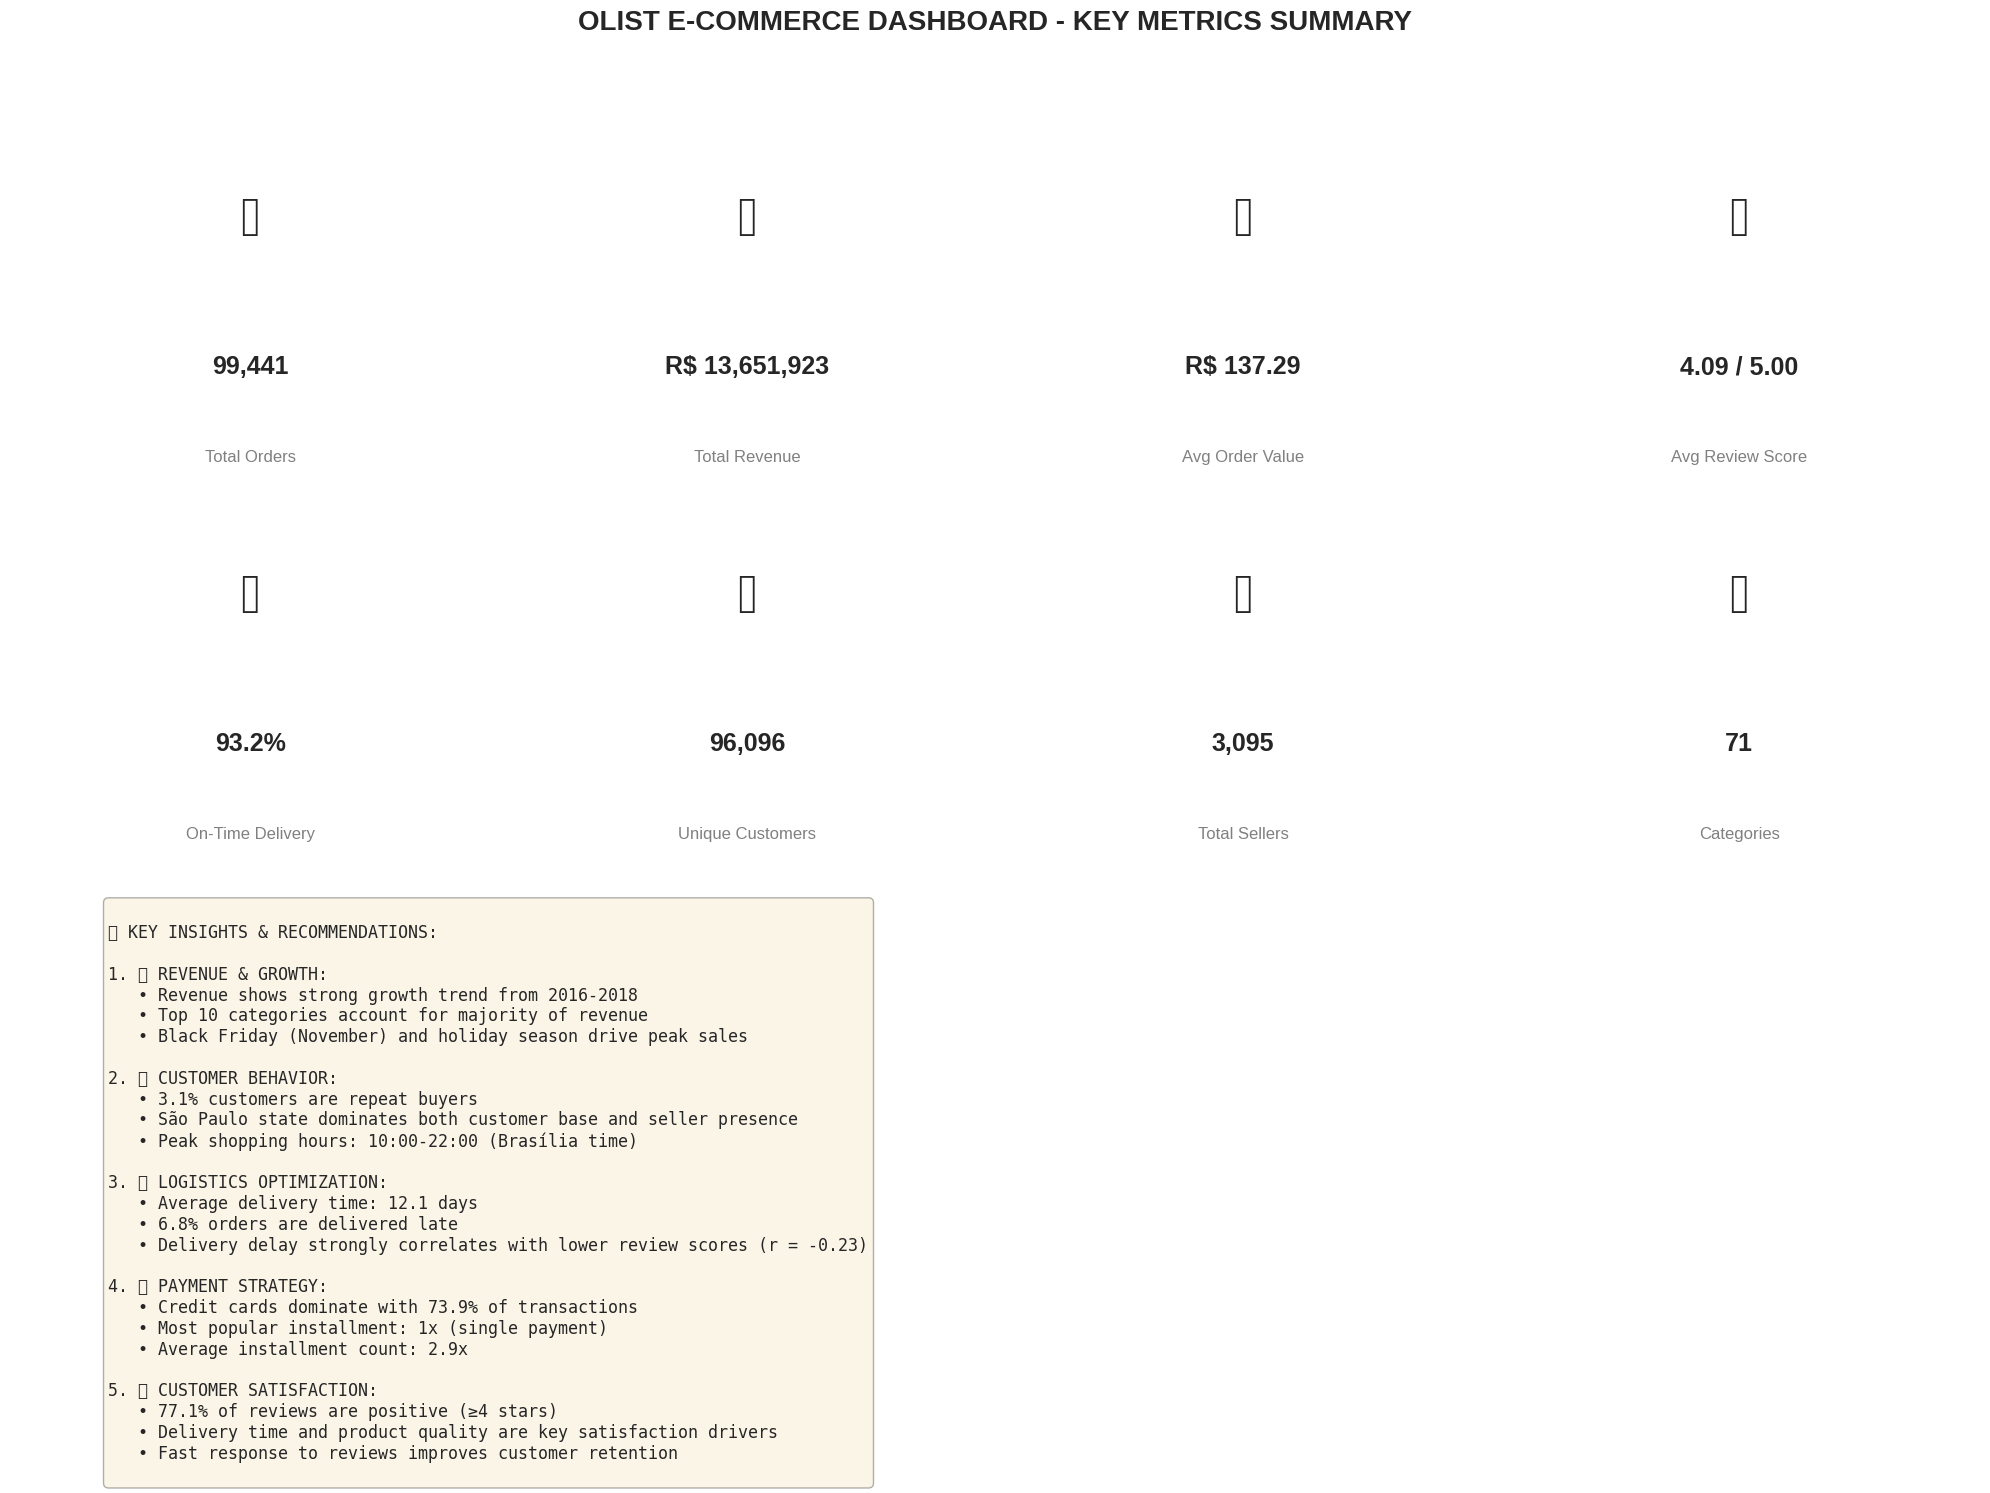

In [30]:
# Summary dashboard
fig = plt.figure(figsize=(20, 16))

# Title
fig.suptitle('OLIST E-COMMERCE DASHBOARD - KEY METRICS SUMMARY', 
             fontsize=20, fontweight='bold', y=0.98)

# KPI cards
kpi_data = [
    ('Total Orders', f'{len(orders):,}', '📦'),
    ('Total Revenue', f'R$ {total_revenue:,.0f}', '💰'),
    ('Avg Order Value', f'R$ {avg_order_value:,.2f}', '🛒'),
    ('Avg Review Score', f'{avg_review:.2f} / 5.00', '⭐'),
    ('On-Time Delivery', f'{on_time/len(delivered_orders)*100:.1f}%', '🚚'),
    ('Unique Customers', f'{unique_customers:,}', '👥'),
    ('Total Sellers', f'{len(sellers):,}', '🏪'),
    ('Categories', f'{len(category_translation)}', '📂')
]

for i, (title, value, icon) in enumerate(kpi_data):
    ax = plt.subplot(3, 4, i+1)
    ax.text(0.5, 0.7, icon, fontsize=40, ha='center', va='center')
    ax.text(0.5, 0.3, value, fontsize=18, ha='center', va='center', fontweight='bold')
    ax.text(0.5, 0.05, title, fontsize=12, ha='center', va='center', color='gray')
    ax.axis('off')

# Additional insights
ax_insight = plt.subplot(3, 1, 3)
ax_insight.axis('off')
insights_text = f"""
📊 KEY INSIGHTS & RECOMMENDATIONS:

1. 📈 REVENUE & GROWTH:
   • Revenue shows strong growth trend from 2016-2018
   • Top 10 categories account for majority of revenue
   • Black Friday (November) and holiday season drive peak sales

2. 👥 CUSTOMER BEHAVIOR:
   • {repeat_customers/unique_customers*100:.1f}% customers are repeat buyers
   • São Paulo state dominates both customer base and seller presence
   • Peak shopping hours: 10:00-22:00 (Brasília time)

3. 🚚 LOGISTICS OPTIMIZATION:
   • Average delivery time: {delivered_orders['delivery_time_days'].mean():.1f} days
   • {late/len(delivered_orders)*100:.1f}% orders are delivered late
   • Delivery delay strongly correlates with lower review scores (r = {master_df['delivery_delay'].corr(master_df['review_score']):.2f})

4. 💳 PAYMENT STRATEGY:
   • Credit cards dominate with {payment_type_counts.get('credit_card', 0)/len(order_payments)*100:.1f}% of transactions
   • Most popular installment: 1x (single payment)
   • Average installment count: {order_payments['payment_installments'].mean():.1f}x

5. ⭐ CUSTOMER SATISFACTION:
   • {positive_reviews/len(order_reviews)*100:.1f}% of reviews are positive (≥4 stars)
   • Delivery time and product quality are key satisfaction drivers
   • Fast response to reviews improves customer retention
"""

ax_insight.text(0.05, 0.9, insights_text, fontsize=12, va='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [31]:
# Export processed data for further analysis
print("Saving processed datasets...")

# Save key processed datasets
master_df.to_csv('olist_master_processed.csv', index=False)
rfm.to_csv('olist_rfm_analysis.csv')
category_stats.to_csv('olist_category_analysis.csv')

print("✅ Files saved:")
print("  • olist_master_processed.csv")
print("  • olist_rfm_analysis.csv")
print("  • olist_category_analysis.csv")
print("\n📊 Analysis Complete! Ready for further exploration.")

Saving processed datasets...


OSError: [Errno 28] No space left on device